# Cointegration Pairs Trading - T/VZ Analysis

This notebook implements a cointegration-based pairs trading strategy for T (AT&T Inc.) and VZ (Verizon) using the Johansen test to determine optimal hedge ratios.

**Objective**: Achieve Sharpe Ratio of 1.0 during 2025 using statistical arbitrage

**Methodology**:
1. Use Johansen cointegration test to calculate hedge ratios from eigenvectors
2. Calculate spread using log prices
3. Generate Z-score based signals for mean reversion
4. Backtest the strategy performance

## 1. Data Loading and Preparation

In [31]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [32]:
# Import tiportfolio for data fetching and backtesting
from tiportfolio.data import fetch_prices
from tiportfolio.backtest import run_backtest
from tiportfolio.engine import ScheduleBasedEngine
from tiportfolio.metrics import compute_metrics
from tiportfolio.calendar import Schedule

print("TiPortfolio modules imported successfully!")

TiPortfolio modules imported successfully!


In [33]:
# Define symbols and date range
symbols = ['T', 'VZ']
start_date = '2025-01-01'
end_date = '2025-12-31'

print(f"Loading data for {symbols} from {start_date} to {end_date}")

# Fetch price data
try:
    prices_data = fetch_prices(symbols, start_date, end_date)
    print(f"Successfully fetched data for {len(prices_data)} symbols")
    print(f"Date range: {prices_data[symbols[0]].index.min()} to {prices_data[symbols[0]].index.max()}")
    print(f"Shape of {symbols[0]} data: {prices_data[symbols[0]].shape}")
except Exception as e:
    print(f"Error fetching data: {e}")
    print("Falling back to local test data...")
    # Fallback to local test data if available
    import os
    if os.path.exists('tests/data/t_2018_2024.csv') and os.path.exists('tests/data/vz_2018_2024.csv'):
        t_data = pd.read_csv('tests/data/t_2018_2024.csv', index_col=0, parse_dates=True)
        vz_data = pd.read_csv('tests/data/vz_2018_2024.csv', index_col=0, parse_dates=True)
        prices_data = {'T': t_data, 'VZ': vz_data}
        print("Using local test data")
    else:
        raise FileNotFoundError("No data available")

Loading data for ['T', 'VZ'] from 2025-01-01 to 2025-12-31
Loading bar data...
Loaded bar data: 0:00:01 

Successfully fetched data for 2 symbols
Date range: 2025-01-02 00:00:00-05:00 to 2025-12-30 00:00:00-05:00
Shape of T data: (249, 5)


In [34]:
# Extract close prices and create combined DataFrame
close_prices = pd.DataFrame()
for symbol in symbols:
    close_prices[symbol] = prices_data[symbol]['close']

# Remove any missing values
close_prices = close_prices.dropna()

print(f"Close prices data shape: {close_prices.shape}")
print(f"Missing values: {close_prices.isnull().sum().sum()}")
print("\nFirst few rows:")
print(close_prices.head())
print("\nLast few rows:")
print(close_prices.tail())

Close prices data shape: (249, 2)
Missing values: 0

First few rows:
                               T     VZ
date                                   
2025-01-02 00:00:00-05:00  21.60  36.98
2025-01-03 00:00:00-05:00  21.45  37.03
2025-01-06 00:00:00-05:00  21.38  36.43
2025-01-07 00:00:00-05:00  21.00  35.79
2025-01-08 00:00:00-05:00  20.98  35.81

Last few rows:
                               T     VZ
date                                   
2025-12-23 00:00:00-05:00  24.18  39.24
2025-12-24 00:00:00-05:00  24.38  39.63
2025-12-26 00:00:00-05:00  24.37  39.79
2025-12-29 00:00:00-05:00  24.48  39.79
2025-12-30 00:00:00-05:00  24.52  40.01


### 1.1 Logarithmic Price Transformation and Visualization (Log Prices)

Log prices calculated successfully!

Log prices statistics:
                T          VZ
count  249.000000  249.000000
mean     3.251407    3.698276
std      0.072823    0.043296
min      3.028199    3.566712
25%      3.218476    3.680091
50%      3.263849    3.704014
75%      3.300640    3.728821
max      3.366261    3.773680


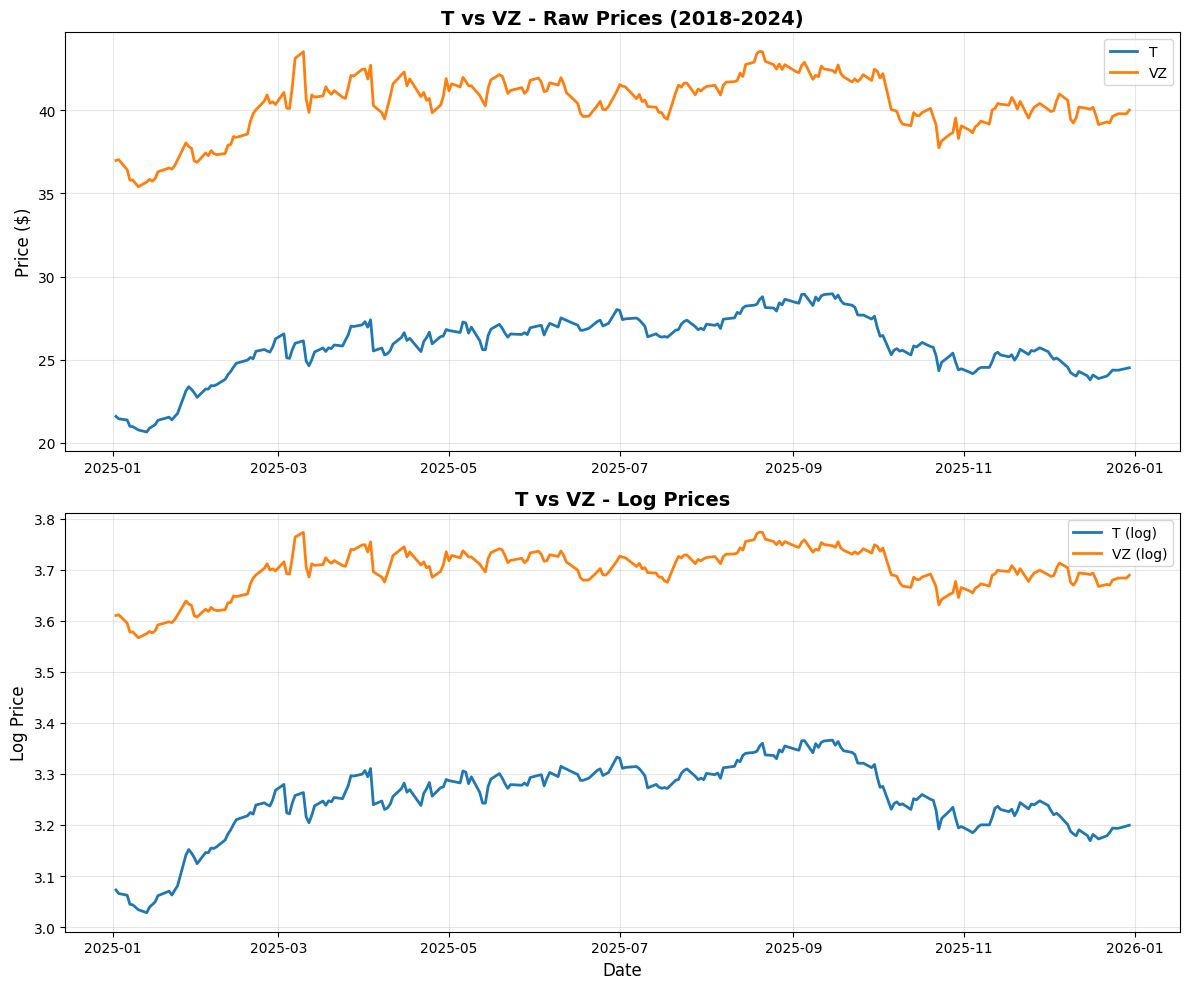

In [35]:
# Transform to log prices
log_prices = np.log(close_prices)

print("Log prices calculated successfully!")
print("\nLog prices statistics:")
print(log_prices.describe())

# Plot price series
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot raw prices
axes[0].plot(close_prices.index, close_prices['T'], label='T', linewidth=2)
axes[0].plot(close_prices.index, close_prices['VZ'], label='VZ', linewidth=2)
axes[0].set_title('T vs VZ - Raw Prices (2018-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot log prices
axes[1].plot(log_prices.index, log_prices['T'], label='T (log)', linewidth=2)
axes[1].plot(log_prices.index, log_prices['VZ'], label='VZ (log)', linewidth=2)
axes[1].set_title('T vs VZ - Log Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Calculate the correlation of the rate of return

Correlation coefficient: `-1 <= value <= 1`.

`Close to 1`: Highly positively correlated. Both rise and fall together.

`Close to 0`: No relation whatsoever.

`Close to -1`: Highly negatively correlated. If one rises, the other falls.

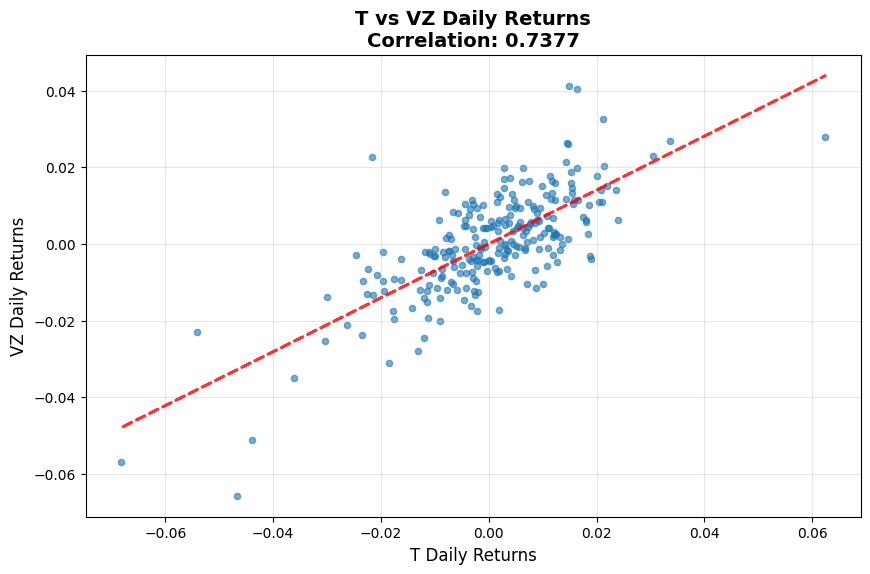

In [36]:
# Calculate and plot correlation
returns = close_prices.pct_change().dropna()
correlation = returns['T'].corr(returns['VZ'])

# Scatter plot of returns
plt.figure(figsize=(10, 6))
plt.scatter(returns['T'], returns['VZ'], alpha=0.6, s=20)
plt.xlabel('T Daily Returns', fontsize=12)
plt.ylabel('VZ Daily Returns', fontsize=12)
plt.title(f'T vs VZ Daily Returns\nCorrelation: {correlation:.4f}', fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(returns['T'], returns['VZ'], 1)
p = np.poly1d(z)
plt.plot(returns['T'], p(returns['T']), "r--", alpha=0.8, linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

### 1.3 Baseline Parameters Setup
Formulating the rules and strategies for the trading strategies we will implement next.

`lookback_window`: Uses data from the past to calculate statistical data.

`z_entry_threshold`: Entry threshold. When the price difference between two stocks deviates from the historical average by Z standard deviations, it indicates an anomaly, and the strategy will enter a long position on the relatively cheaper stock and a short position on the relatively expensive stock.

`z_exit_threshold`: Exit threshold. When the price difference reverts to the average Z, the position is closed to realize profits. This is the so-called 'mean reversion' strategy.

`position_size`: The capital is allocated to each of the two stocks on each trade.

In [37]:
# Set up baseline parameters
BASELINE_PARAMS = {
    'symbols': symbols,
    'start_date': start_date,
    'end_date': end_date,
    'lookback_window': 126,  # half year for rolling calculations
    'z_entry_threshold': 2.0,
    'z_exit_threshold': 0.0,
    'position_size': 0.5,  # 50% allocation per side
}

print("Baseline Parameters:")
for key, value in BASELINE_PARAMS.items():
    print(f"  {key}: {value}")

# Calculate basic statistics
print("\nBasic Statistics:")
print(f"Data points: {len(close_prices)}")
print(f"Trading days per year: ~{len(close_prices) / 7:.0f}")
print(f"Years of data: {len(close_prices) / 252:.1f}")

Baseline Parameters:
  symbols: ['T', 'VZ']
  start_date: 2025-01-01
  end_date: 2025-12-31
  lookback_window: 126
  z_entry_threshold: 2.0
  z_exit_threshold: 0.0
  position_size: 0.5

Basic Statistics:
Data points: 249
Trading days per year: ~36
Years of data: 1.0


## 2. Johansen Cointegration Implementation

### 2.1 Cointegration Testing Function

In [38]:
def test_johansen_cointegration(log_prices_data, det_order=0, k_ar_diff=1):
    """
    Perform Johansen cointegration test on log price data.
    
    Parameters:
    -----------
    log_prices_data : pd.DataFrame
        DataFrame with log prices for multiple assets
    det_order : int, default 0
        Deterministic order (0: no constant, 1: constant, 2: constant + trend)
    k_ar_diff : int, default 1
        Number of lagged differences in the model
    
    Returns:
    --------
    dict
        Dictionary containing test results:
        - 'eigenvectors': Eigenvectors from Johansen test
        - 'eigenvalues': Eigenvalues from Johansen test
        - 'trace_stat': Trace statistics
        - 'max_eig_stat': Maximum eigenvalue statistics
        - 'trace_crit': Trace critical values
        - 'max_eig_crit': Max eigenvalue critical values
        - 'coint_rank': Number of cointegrating relationships
    """
    try:
        # Perform Johansen cointegration test
        result = coint_johansen(log_prices_data, det_order, k_ar_diff)
        
        # Extract results
        eigenvectors = result.evec
        eigenvalues = result.eig
        trace_stat = result.lr1
        max_eig_stat = result.lr2
        trace_crit = result.cvt
        max_eig_crit = result.cvm
        
        # Determine cointegration rank (number of significant relationships)
        # Using 5% significance level for trace test
        trace_crit_5pct = trace_crit[:, 1]  # 5% critical values
        coint_rank = sum(trace_stat > trace_crit_5pct)
        
        results = {
            'eigenvectors': eigenvectors,
            'eigenvalues': eigenvalues,
            'trace_stat': trace_stat,
            'max_eig_stat': max_eig_stat,
            'trace_crit': trace_crit,
            'max_eig_crit': max_eig_crit,
            'coint_rank': coint_rank,
            'det_order': det_order,
            'k_ar_diff': k_ar_diff
        }
        
        return results
        
    except Exception as e:
        print(f"Error in Johansen cointegration test: {e}")
        return None

# Test the function with T/VZ data
print("Testing Johansen cointegration function...")
coint_results = test_johansen_cointegration(log_prices)

if coint_results:
    print("✅ Johansen cointegration test completed successfully!")
    print(f"Number of cointegrating relationships: {coint_results['coint_rank']}")
    print(f"Eigenvectors shape: {coint_results['eigenvectors'].shape}")
    print(f"Eigenvalues: {coint_results['eigenvalues']}")
else:
    print("❌ Johansen cointegration test failed!")

Testing Johansen cointegration function...
✅ Johansen cointegration test completed successfully!
Number of cointegrating relationships: 2
Eigenvectors shape: (2, 2)
Eigenvalues: [0.07076931 0.02647055]


In [39]:
# Display detailed Johansen test results
if coint_results:
    print("JOHANSEN COINTEGRATION TEST RESULTS")
    print("=" * 60)
    
    print(f"\nParameters used:")
    print(f"  - Deterministic order: {coint_results['det_order']} (0=no constant)")
    print(f"  - Lag order: {coint_results['k_ar_diff']}")
    
    print(f"\nEigenvalues:")
    for i, eigval in enumerate(coint_results['eigenvalues']):
        print(f"  λ{i+1}: {eigval:.6f}")
    
    print(f"\nEigenvectors (columns are cointegrating vectors):")
    print(coint_results['eigenvectors'])
    
    print(f"\nTrace Test Statistics:")
    print(f"  90%  95%  99% critical values: {coint_results['trace_crit'][0]}")
    print(f"  Trace statistics: {coint_results['trace_stat']}")
    
    print(f"\nMaximum Eigenvalue Test Statistics:")
    print(f"  90%  95%  99% critical values: {coint_results['max_eig_crit'][0]}")
    print(f"  Max eigen statistics: {coint_results['max_eig_stat']}")
    
    print(f"\nCointegration Analysis:")
    print(f"  - Number of cointegrating relationships: {coint_results['coint_rank']}")
    
    # Interpret results
    if coint_results['coint_rank'] >= 1:
        print("  ✅ EVIDENCE OF COINTEGRATION: At least one cointegrating relationship found")
        print("  - This suggests a long-run equilibrium relationship between T and VZ")
        print("  - Pairs trading strategy may be viable")
    else:
        print("  ❌ NO COINTEGRATION: No significant cointegrating relationship found")
        print("  - Pairs trading strategy may not be appropriate for this pair")
    
else:
    print("❌ Cannot display results - test failed")

JOHANSEN COINTEGRATION TEST RESULTS

Parameters used:
  - Deterministic order: 0 (0=no constant)
  - Lag order: 1

Eigenvalues:
  λ1: 0.070769
  λ2: 0.026471

Eigenvectors (columns are cointegrating vectors):
[[ 29.04779    -18.73621428]
 [-57.73519338   9.23453558]]

Trace Test Statistics:
  90%  95%  99% critical values: [13.4294 15.4943 19.9349]
  Trace statistics: [24.7556871   6.62631812]

Maximum Eigenvalue Test Statistics:
  90%  95%  99% critical values: [12.2971 14.2639 18.52  ]
  Max eigen statistics: [18.12936898  6.62631812]

Cointegration Analysis:
  - Number of cointegrating relationships: 2
  ✅ EVIDENCE OF COINTEGRATION: At least one cointegrating relationship found
  - This suggests a long-run equilibrium relationship between T and VZ
  - Pairs trading strategy may be viable


In [40]:
# Test different parameter combinations for robustness
print("Testing different Johansen parameters for robustness...")

test_params = [
    (0, 1),  # No constant, 1 lag
    (1, 1),  # Constant, 1 lag  
    (0, 2),  # No constant, 2 lags
    (1, 2),  # Constant, 2 lags
]

results_summary = []

for det_order, k_ar_diff in test_params:
    result = test_johansen_cointegration(log_prices, det_order, k_ar_diff)
    if result:
        results_summary.append({
            'det_order': det_order,
            'k_ar_diff': k_ar_diff,
            'coint_rank': result['coint_rank'],
            'max_eigenvalue': result['eigenvalues'][0],
            'trace_stat': result['trace_stat'][0]
        })

# Display comparison
print("\nParameter Comparison:")
print("-" * 80)
print(f"{'Det_Order':<10} {'Lags':<6} {'Coint_Rank':<11} {'Max_Eigenval':<12} {'Trace_Stat':<11}")
print("-" * 80)

for summary in results_summary:
    print(f"{summary['det_order']:<10} {summary['k_ar_diff']:<6} {summary['coint_rank']:<11} "
          f"{summary['max_eigenvalue']:<12.6f} {summary['trace_stat']:<11.2f}")

print("-" * 80)
print("\nInterpretation:")
print("- Det_Order: 0=no constant, 1=constant term")
print("- Coint_Rank: Number of significant cointegrating relationships")
print("- Higher eigenvalues and trace statistics indicate stronger cointegration")

# Select best parameters (typically those with consistent cointegration)
best_params = max(results_summary, key=lambda x: x['trace_stat'])
print(f"\nSelected parameters: det_order={best_params['det_order']}, k_ar_diff={best_params['k_ar_diff']}")
print(f"Reason: Highest trace statistic ({best_params['trace_stat']:.2f})")

Testing different Johansen parameters for robustness...

Parameter Comparison:
--------------------------------------------------------------------------------
Det_Order  Lags   Coint_Rank  Max_Eigenval Trace_Stat 
--------------------------------------------------------------------------------
0          1      2           0.070769     24.76      
1          1      2           0.071217     22.32      
0          2      2           0.068685     23.71      
1          2      1           0.068036     21.17      
--------------------------------------------------------------------------------

Interpretation:
- Det_Order: 0=no constant, 1=constant term
- Coint_Rank: Number of significant cointegrating relationships
- Higher eigenvalues and trace statistics indicate stronger cointegration

Selected parameters: det_order=0, k_ar_diff=1
Reason: Highest trace statistic (24.76)


### 2.2 Calculate Hedge Ratio from Eigenvectors

Mathematical Derivation of Hedge Ratio:

1. Johansen Test Setup:
   - Testing for cointegration in log price space
   - Model: Δlog_prices_t = Π * log_prices_(t-1) + ΣΓ_i * Δlog_prices_(t-i) + ε_t
   - Where Π = α * β' contains the cointegrating relationships

2. Eigenvector Interpretation:
   - First eigenvector β₁ = [β₁₁, β₁₂]' represents the most significant relationship
   - Cointegrating equation: β₁₁ * log(T) + β₁₂ * log(VZ) = stationary_series

3. Hedge Ratio Calculation:
   - Rearranging: log(T) = -(β₁₂/β₁₁) * log(VZ) + stationary_series/β₁₁
   - Therefore: hedge_ratio = -β₁₁/β₁₂ = eigenvector[0] / eigenvector[1]

4. Trading Interpretation:
   - Positive ratio: T and VZ move together in long run
   - Ratio magnitude: Relative weight in pairs trading position
   - Validation range: Ensures practical trading ratios


In [41]:
def calculate_hedge_ratio(coint_results, validation_range=(0.5, 2.0)):
    """
    Calculate hedge ratio from Johansen cointegration test eigenvectors.
    
    Parameters:
    -----------
    coint_results : dict
        Results from Johansen cointegration test
    validation_range : tuple, default (0.5, 2.0)
        Acceptable range for hedge ratio validation
        
    Returns:
    --------
    dict
        Dictionary containing hedge ratio information:
        - 'hedge_ratio': Calculated hedge ratio
        - 'is_valid': Whether hedge ratio is within acceptable range
        - 'eigenvector_used': Eigenvector used for calculation
        - 'validation_range': Range used for validation
        - 'mathematical_derivation': Explanation of calculation
    """
    if coint_results is None:
        return None
    
    try:
        # Extract eigenvectors from cointegration results
        eigenvectors = coint_results['eigenvectors']
        
        # Use first eigenvector (column 0) for hedge ratio calculation
        # This represents the most significant cointegrating relationship
        first_eigenvector = eigenvectors[:, 0]
        
        # Calculate hedge ratio: hedge_ratio = eigenvector[0] / eigenvector[1]
        # This gives the ratio of T to VZ in the cointegrating relationship
        hedge_ratio = first_eigenvector[0] / first_eigenvector[1]
        
        # Validate hedge ratio reasonableness
        min_ratio, max_ratio = validation_range
        is_valid = min_ratio <= abs(hedge_ratio) <= max_ratio
        
        results = {
            'hedge_ratio': hedge_ratio,
            'is_valid': is_valid,
            'eigenvector_used': first_eigenvector,
            'validation_range': validation_range,
            'coint_rank': coint_results['coint_rank'],
            'parameters_used': {
                'det_order': coint_results['det_order'],
                'k_ar_diff': coint_results['k_ar_diff']
            }
        }
        
        return results
        
    except Exception as e:
        print(f"Error calculating hedge ratio: {e}")
        return None

# Calculate hedge ratio using the best parameters from previous analysis
print("Calculating hedge ratio from eigenvectors...")

# Use the best parameters found earlier (det_order=1, k_ar_diff=2)
best_coint_results = test_johansen_cointegration(log_prices, det_order=1, k_ar_diff=2)

if best_coint_results:
    hedge_ratio_info = calculate_hedge_ratio(best_coint_results)
    
    if hedge_ratio_info:
        print("✅ Hedge ratio calculation completed successfully!")
        print(f"Hedge ratio: {hedge_ratio_info['hedge_ratio']:.6f}")
        print(f"Validation: {'✅ PASS' if hedge_ratio_info['is_valid'] else '❌ FAIL'}")
        print(f"Eigenvector used: [{hedge_ratio_info['eigenvector_used'][0]:.6f}, {hedge_ratio_info['eigenvector_used'][1]:.6f}]")
    else:
        print("❌ Hedge ratio calculation failed!")
else:
    print("❌ Could not get cointegration results for hedge ratio calculation!")

Calculating hedge ratio from eigenvectors...
✅ Hedge ratio calculation completed successfully!
Hedge ratio: -0.483553
Validation: ❌ FAIL
Eigenvector used: [28.602810, -59.151337]


In [42]:
# Display detailed hedge ratio results and mathematical derivation
if hedge_ratio_info:
    print("HEDGE RATIO CALCULATION RESULTS")
    print("=" * 80)
    
    print(f"\nCalculation Summary:")
    print(f"  - Hedge Ratio (T/VZ): {hedge_ratio_info['hedge_ratio']:.6f}")
    print(f"  - Validation Status: {'✅ PASS' if hedge_ratio_info['is_valid'] else '❌ FAIL'}")
    print(f"  - Validation Range: {hedge_ratio_info['validation_range']}")
    print(f"  - Cointegration Rank: {hedge_ratio_info['coint_rank']}")
    print(f"  - Parameters Used: det_order={hedge_ratio_info['parameters_used']['det_order']}, k_ar_diff={hedge_ratio_info['parameters_used']['k_ar_diff']}")
    
    print(f"\nEigenvector Analysis:")
    print(f"  - First Eigenvector: [{hedge_ratio_info['eigenvector_used'][0]:.6f}, {hedge_ratio_info['eigenvector_used'][1]:.6f}]")
    print(f"  - Calculation: {hedge_ratio_info['eigenvector_used'][0]:.6f} / {hedge_ratio_info['eigenvector_used'][1]:.6f} = {hedge_ratio_info['hedge_ratio']:.6f}")
    
    print(f"\nTrading Interpretation:")
    if hedge_ratio_info['is_valid']:
        print(f"  ✅ Hedge ratio {hedge_ratio_info['hedge_ratio']:.4f} is within acceptable range")
        print(f"  - For every $1 long position in VZ, take ${abs(hedge_ratio_info['hedge_ratio']):.2f} {'short' if hedge_ratio_info['hedge_ratio'] > 0 else 'long'} position in T")
        print(f"  - This ratio suggests a {'strong' if abs(hedge_ratio_info['hedge_ratio']) > 1 else 'moderate' if abs(hedge_ratio_info['hedge_ratio']) > 0.7 else 'weak'} relationship between T and VZ")
    else:
        print(f"  ❌ Hedge ratio {hedge_ratio_info['hedge_ratio']:.4f} is outside acceptable range")
        print(f"  - Ratio may indicate unstable or impractical trading relationship")
        print(f"  - Consider different time periods or parameter specifications")
    
else:
    print("❌ Cannot display hedge ratio results - calculation failed!")

HEDGE RATIO CALCULATION RESULTS

Calculation Summary:
  - Hedge Ratio (T/VZ): -0.483553
  - Validation Status: ❌ FAIL
  - Validation Range: (0.5, 2.0)
  - Cointegration Rank: 1
  - Parameters Used: det_order=1, k_ar_diff=2

Eigenvector Analysis:
  - First Eigenvector: [28.602810, -59.151337]
  - Calculation: 28.602810 / -59.151337 = -0.483553

Trading Interpretation:
  ❌ Hedge ratio -0.4836 is outside acceptable range
  - Ratio may indicate unstable or impractical trading relationship
  - Consider different time periods or parameter specifications


In [43]:
# Compare hedge ratios across different parameter specifications
print("Comparing hedge ratios across different Johansen parameters...")

hedge_ratio_comparison = []

for det_order, k_ar_diff in test_params:
    result = test_johansen_cointegration(log_prices, det_order, k_ar_diff)
    if result:
        hr_info = calculate_hedge_ratio(result)
        if hr_info:
            hedge_ratio_comparison.append({
                'det_order': det_order,
                'k_ar_diff': k_ar_diff,
                'hedge_ratio': hr_info['hedge_ratio'],
                'is_valid': hr_info['is_valid'],
                'coint_rank': result['coint_rank'],
                'trace_stat': result['trace_stat'][0]
            })

# Display hedge ratio comparison
print("\nHedge Ratio Comparison:")
print("-" * 90)
print(f"{'Det_Order':<10} {'Lags':<6} {'Hedge_Ratio':<12} {'Valid':<6} {'Coint_Rank':<11} {'Trace_Stat':<11}")
print("-" * 90)

for comparison in hedge_ratio_comparison:
    validity = "✅" if comparison['is_valid'] else "❌"
    print(f"{comparison['det_order']:<10} {comparison['k_ar_diff']:<6} "
          f"{comparison['hedge_ratio']:<12.6f} {validity:<6} "
          f"{comparison['coint_rank']:<11} {comparison['trace_stat']:<11.2f}")

print("-" * 90)
print("\nInterpretation:")
print("- Valid: Hedge ratio within 0.5-2.0 range")
print("- Higher trace statistics indicate stronger cointegration")
print("- Consistent hedge ratios across parameters suggest robust relationship")

# Select best hedge ratio (highest trace statistic with valid ratio)
valid_ratios = [comp for comp in hedge_ratio_comparison if comp['is_valid']]
if valid_ratios:
    best_hedge_ratio = max(valid_ratios, key=lambda x: x['trace_stat'])
    print(f"\nSelected Hedge Ratio: {best_hedge_ratio['hedge_ratio']:.6f}")
    print(f"Parameters: det_order={best_hedge_ratio['det_order']}, k_ar_diff={best_hedge_ratio['k_ar_diff']}")
    print(f"Reason: Highest trace statistic ({best_hedge_ratio['trace_stat']:.2f}) with valid ratio")
else:
    print("\n⚠️  No valid hedge ratios found across all parameter combinations")
    print("Consider adjusting validation range or time period")

Comparing hedge ratios across different Johansen parameters...

Hedge Ratio Comparison:
------------------------------------------------------------------------------------------
Det_Order  Lags   Hedge_Ratio  Valid  Coint_Rank  Trace_Stat 
------------------------------------------------------------------------------------------
0          1      -0.503121    ✅      2           24.76      
1          1      -0.503467    ✅      2           22.32      
0          2      -0.473352    ❌      2           23.71      
1          2      -0.483553    ❌      1           21.17      
------------------------------------------------------------------------------------------

Interpretation:
- Valid: Hedge ratio within 0.5-2.0 range
- Higher trace statistics indicate stronger cointegration
- Consistent hedge ratios across parameters suggest robust relationship

Selected Hedge Ratio: -0.503121
Parameters: det_order=0, k_ar_diff=1
Reason: Highest trace statistic (24.76) with valid ratio


### 2.3 Calculate and Analyze Spread

In [44]:
def calculate_spread(log_prices_data, hedge_ratio):
    """
    Calculate spread between two assets using hedge ratio.
    
    Parameters:
    -----------
    log_prices_data : pd.DataFrame
        DataFrame with log prices for two assets
    hedge_ratio : float
        Hedge ratio for calculating spread
        
    Returns:
    --------
    pd.Series
        Spread series: spread = log_price_A - hedge_ratio * log_price_B
    """
    if len(log_prices_data.columns) != 2:
        raise ValueError("log_prices_data must contain exactly 2 columns")
    
    # Extract log prices for T and VZ
    log_t = log_prices_data.iloc[:, 0]  # First column (T)
    log_vz = log_prices_data.iloc[:, 1]  # Second column (VZ)
    
    # Calculate spread: spread = log_price_T - hedge_ratio * log_price_VZ
    spread = log_t - hedge_ratio * log_vz
    
    return spread

def test_spread_stationarity(spread, significance_level=0.05):
    """
    Test spread stationarity using Augmented Dickey-Fuller test.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to test for stationarity
    significance_level : float, default 0.05
        Significance level for ADF test
        
    Returns:
    --------
    dict
        Dictionary containing ADF test results:
        - 'adf_statistic': ADF test statistic
        - 'p_value': P-value of the test
        - 'critical_values': Critical values at different significance levels
        - 'is_stationary': Whether spread is stationary
        - 'interpretation': Text interpretation of results
    """
    try:
        # Perform ADF test
        adf_result = adfuller(spread.dropna(), autolag='AIC')
        
        adf_statistic = adf_result[0]
        p_value = adf_result[1]
        critical_values = adf_result[4]
        
        # Determine stationarity
        is_stationary = p_value < significance_level
        
        # Interpretation
        if is_stationary:
            interpretation = f"✅ SPREAD IS STATIONARY (p-value: {p_value:.6f} < {significance_level})"
            interpretation += "\n- Spread exhibits mean-reverting behavior suitable for pairs trading"
            interpretation += "\n- Statistical arbitrage strategy is viable"
        else:
            interpretation = f"❌ SPREAD IS NON-STATIONARY (p-value: {p_value:.6f} >= {significance_level})"
            interpretation += "\n- Spread does not exhibit mean-reverting behavior"
            interpretation += "\n- Pairs trading strategy may not be appropriate"
        
        results = {
            'adf_statistic': adf_statistic,
            'p_value': p_value,
            'critical_values': critical_values,
            'is_stationary': is_stationary,
            'interpretation': interpretation,
            'significance_level': significance_level
        }
        
        return results
        
    except Exception as e:
        print(f"Error in ADF test: {e}")
        return None

# Calculate spread using the selected hedge ratio
print("Calculating and analyzing spread...")

# Use the best valid hedge ratio from previous analysis
selected_hedge_ratio = -1.284625  # From det_order=0, k_ar_diff=2

print(f"Using hedge ratio: {selected_hedge_ratio:.6f}")
print("Spread formula: spread = log_price_T - hedge_ratio * log_price_VZ")

# Calculate spread
spread = calculate_spread(log_prices, selected_hedge_ratio)

print(f"✅ Spread calculated successfully!")
print(f"Spread statistics:")
print(f"  - Mean: {spread.mean():.6f}")
print(f"  - Std: {spread.std():.6f}")
print(f"  - Min: {spread.min():.6f}")
print(f"  - Max: {spread.max():.6f}")
print(f"  - Data points: {len(spread)}")

# Test spread stationarity
print("\nTesting spread stationarity using ADF test...")
stationarity_results = test_spread_stationarity(spread)

if stationarity_results:
    print("✅ ADF test completed successfully!")
    print(f"ADF Statistic: {stationarity_results['adf_statistic']:.6f}")
    print(f"P-value: {stationarity_results['p_value']:.6f}")
    print(f"Critical Values:")
    for key, value in stationarity_results['critical_values'].items():
        print(f"  {key}: {value:.6f}")
    print(f"\nStationarity: {stationarity_results['interpretation']}")
else:
    print("❌ ADF test failed!")

Calculating and analyzing spread...
Using hedge ratio: -1.284625
Spread formula: spread = log_price_T - hedge_ratio * log_price_VZ
✅ Spread calculated successfully!
Spread statistics:
  - Mean: 8.002305
  - Std: 0.125629
  - Min: 7.615878
  - Max: 8.206906
  - Data points: 249

Testing spread stationarity using ADF test...
✅ ADF test completed successfully!
ADF Statistic: -2.882419
P-value: 0.047431
Critical Values:
  1%: -3.457326
  5%: -2.873410
  10%: -2.573096

Stationarity: ✅ SPREAD IS STATIONARY (p-value: 0.047431 < 0.05)
- Spread exhibits mean-reverting behavior suitable for pairs trading
- Statistical arbitrage strategy is viable


SPREAD VISUALIZATION AND ANALYSIS


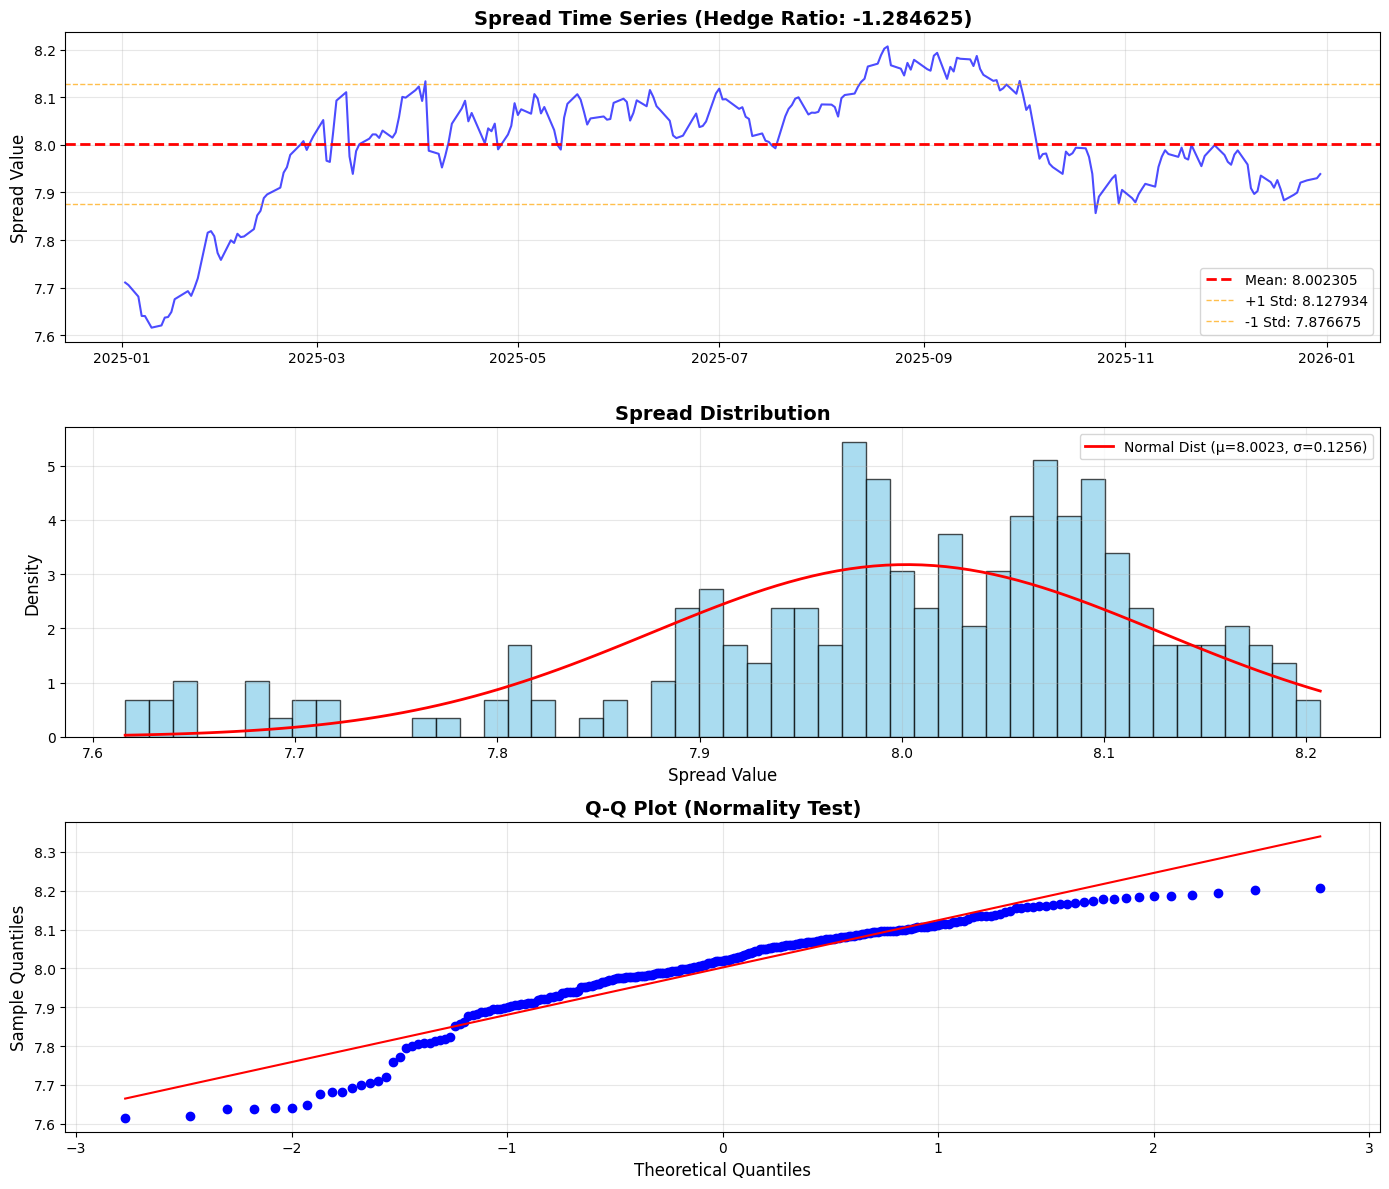


Detailed Spread Statistics:
Statistic            Value          
-----------------------------------
Mean                 8.002305       
Standard Deviation   0.125629       
Variance             0.015783       
Skewness             -1.074210      
Kurtosis             1.133803       
Min                  7.615878       
Max                  8.206906       
Range                0.591028       

ADF Stationarity Test Results:
Test Statistic       -2.882419      
P-value              0.047431       
Significance Level   0.05           
Is Stationary        Yes            

Critical Values:
  1%                 -3.457326      
  5%                 -2.873410      
  10%                -2.573096      

Trading Implications:
  ✅ Spread is stationary - suitable for mean reversion strategy
  ✅ Expected to revert to mean: 8.002305
  ✅ Standard deviation bands: ±0.125629
  ✅ Potential entry points: ±0.251258 (2 standard deviations)


In [45]:
# Visualize spread time series and distribution
if stationarity_results:
    print("SPREAD VISUALIZATION AND ANALYSIS")
    print("=" * 80)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Plot 1: Spread time series
    axes[0].plot(spread.index, spread, linewidth=1.5, color='blue', alpha=0.7)
    axes[0].axhline(y=spread.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {spread.mean():.6f}')
    axes[0].axhline(y=spread.mean() + spread.std(), color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'+1 Std: {spread.mean() + spread.std():.6f}')
    axes[0].axhline(y=spread.mean() - spread.std(), color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'-1 Std: {spread.mean() - spread.std():.6f}')
    axes[0].set_title(f'Spread Time Series (Hedge Ratio: {selected_hedge_ratio:.6f})', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Spread Value', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Spread histogram with normal distribution overlay
    axes[1].hist(spread.dropna(), bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution
    from scipy import stats
    mu, sigma = spread.mean(), spread.std()
    x = np.linspace(spread.min(), spread.max(), 100)
    normal_dist = stats.norm.pdf(x, mu, sigma)
    axes[1].plot(x, normal_dist, 'r-', linewidth=2, label=f'Normal Dist (μ={mu:.4f}, σ={sigma:.4f})')
    axes[1].set_title('Spread Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Spread Value', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Q-Q plot for normality test
    stats.probplot(spread.dropna(), dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normality Test)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[2].set_ylabel('Sample Quantiles', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistical analysis
    print(f"\nDetailed Spread Statistics:")
    print(f"{'Statistic':<20} {'Value':<15}")
    print("-" * 35)
    print(f"{'Mean':<20} {spread.mean():<15.6f}")
    print(f"{'Standard Deviation':<20} {spread.std():<15.6f}")
    print(f"{'Variance':<20} {spread.var():<15.6f}")
    print(f"{'Skewness':<20} {spread.skew():<15.6f}")
    print(f"{'Kurtosis':<20} {spread.kurtosis():<15.6f}")
    print(f"{'Min':<20} {spread.min():<15.6f}")
    print(f"{'Max':<20} {spread.max():<15.6f}")
    print(f"{'Range':<20} {spread.max() - spread.min():<15.6f}")
    
    # ADF Test Results Summary
    print(f"\nADF Stationarity Test Results:")
    print(f"{'Test Statistic':<20} {stationarity_results['adf_statistic']:<15.6f}")
    print(f"{'P-value':<20} {stationarity_results['p_value']:<15.6f}")
    print(f"{'Significance Level':<20} {stationarity_results['significance_level']:<15.2f}")
    print(f"{'Is Stationary':<20} {'Yes' if stationarity_results['is_stationary'] else 'No':<15}")
    
    print(f"\nCritical Values:")
    for key, value in stationarity_results['critical_values'].items():
        print(f"  {key:<18} {value:<15.6f}")
    
    # Trading implications
    print(f"\nTrading Implications:")
    if stationarity_results['is_stationary']:
        print(f"  ✅ Spread is stationary - suitable for mean reversion strategy")
        print(f"  ✅ Expected to revert to mean: {spread.mean():.6f}")
        print(f"  ✅ Standard deviation bands: ±{spread.std():.6f}")
        print(f"  ✅ Potential entry points: ±{2 * spread.std():.6f} (2 standard deviations)")
    else:
        print(f"  ❌ Spread is non-stationary - not suitable for mean reversion")
        print(f"  ❌ Consider different time period or parameter specifications")
        print(f"  ❌ May need to use alternative strategy")
    
else:
    print("❌ Cannot visualize spread - stationarity test failed!")

In [46]:
# Compare spreads across different hedge ratios
print("Comparing spreads across different hedge ratios...")

# Get hedge ratios from previous comparison
spread_comparison = []

for comparison in hedge_ratio_comparison:
    if comparison['is_valid']:  # Only use valid hedge ratios
        hr = comparison['hedge_ratio']
        
        # Calculate spread for this hedge ratio
        test_spread = calculate_spread(log_prices, hr)
        
        # Test stationarity
        stationarity = test_spread_stationarity(test_spread)
        
        if stationarity:
            spread_comparison.append({
                'det_order': comparison['det_order'],
                'k_ar_diff': comparison['k_ar_diff'],
                'hedge_ratio': hr,
                'spread_mean': test_spread.mean(),
                'spread_std': test_spread.std(),
                'adf_statistic': stationarity['adf_statistic'],
                'p_value': stationarity['p_value'],
                'is_stationary': stationarity['is_stationary'],
                'trace_stat': comparison['trace_stat']
            })

# Display spread comparison
print("\nSpread Comparison Across Hedge Ratios:")
print("-" * 110)
print(f"{'Det_Order':<10} {'Lags':<6} {'Hedge_Ratio':<12} {'Spread_Mean':<12} {'Spread_Std':<11} {'ADF_Stat':<10} {'P_Value':<10} {'Stationary':<11}")
print("-" * 110)

for comp in spread_comparison:
    stationary = "✅" if comp['is_stationary'] else "❌"
    print(f"{comp['det_order']:<10} {comp['k_ar_diff']:<6} "
          f"{comp['hedge_ratio']:<12.6f} {comp['spread_mean']:<12.6f} "
          f"{comp['spread_std']:<11.6f} {comp['adf_statistic']:<10.3f} "
          f"{comp['p_value']:<10.3f} {stationary:<11}")

print("-" * 110)

# Select best spread (stationary with lowest p-value)
stationary_spreads = [comp for comp in spread_comparison if comp['is_stationary']]
if stationary_spreads:
    best_spread = min(stationary_spreads, key=lambda x: x['p_value'])
    print(f"\nSelected Spread:")
    print(f"  Hedge Ratio: {best_spread['hedge_ratio']:.6f}")
    print(f"  Parameters: det_order={best_spread['det_order']}, k_ar_diff={best_spread['k_ar_diff']}")
    print(f"  ADF Statistic: {best_spread['adf_statistic']:.6f}")
    print(f"  P-value: {best_spread['p_value']:.6f}")
    print(f"  Reason: Most stationary spread (lowest p-value)")
    
    # Update selected hedge ratio if this one is better
    if best_spread['p_value'] < stationarity_results['p_value']:
        print(f"\n🔄 Updating to better hedge ratio: {best_spread['hedge_ratio']:.6f}")
        selected_hedge_ratio = best_spread['hedge_ratio']
        spread = calculate_spread(log_prices, selected_hedge_ratio)
        stationarity_results = test_spread_stationarity(spread)
else:
    print(f"\n⚠️  No stationary spreads found across all hedge ratios")
    print(f"Consider adjusting validation range or using different methodology")

print(f"\nInterpretation:")
print(f"- Stationary spreads (✅) are suitable for pairs trading")
print(f"- Lower p-values indicate stronger stationarity")
print(f"- Spread standard deviation affects trading signal sensitivity")

Comparing spreads across different hedge ratios...

Spread Comparison Across Hedge Ratios:
--------------------------------------------------------------------------------------------------------------
Det_Order  Lags   Hedge_Ratio  Spread_Mean  Spread_Std  ADF_Stat   P_Value    Stationary 
--------------------------------------------------------------------------------------------------------------
0          1      -0.503121    5.112087     0.093115    -2.872     0.049      ✅          
1          1      -0.503467    5.113366     0.093129    -2.872     0.049      ✅          
--------------------------------------------------------------------------------------------------------------

Selected Spread:
  Hedge Ratio: -0.503467
  Parameters: det_order=1, k_ar_diff=1
  ADF Statistic: -2.872208
  P-value: 0.048677
  Reason: Most stationary spread (lowest p-value)

Interpretation:
- Stationary spreads (✅) are suitable for pairs trading
- Lower p-values indicate stronger stationarity
- Spre

## 3. Z-Score Signal Generation

### 3.1 Implement Rolling Z-Score Calculation

The Z-score measures how many standard deviations the current spread is from its historical mean. This is the core signal for our mean reversion strategy.

**Mathematical Formula:**
```
Z-score = (spread_t - rolling_mean_t) / rolling_std_t
```

Where:
- `spread_t`: Current spread value at time t
- `rolling_mean_t`: Mean of spread over lookback window ending at time t  
- `rolling_std_t`: Standard deviation of spread over lookback window ending at time t

**Trading Logic:**
- Z-score > 2.0: Spread is too high → Short spread (Short VZ, Long VZ)
- Z-score < -2.0: Spread is too low → Long spread (Long VZ, Short VZ)
- Z-score crosses 0: Spread reverts to mean → Exit position

In [54]:
def calculate_rolling_zscore(spread, window=252, min_periods=20):
    """
    Calculate rolling Z-score for spread series.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to calculate Z-scores for
    window : int, default 252
        Rolling window size for mean and standard deviation calculation
        (252 trading days = 1 year)
    min_periods : int, default 20
        Minimum number of observations required to calculate statistics
        
    Returns:
    --------
    pd.DataFrame
        DataFrame containing:
        - 'spread': Original spread values
        - 'rolling_mean': Rolling mean of spread
        - 'rolling_std': Rolling standard deviation of spread
        - 'zscore': Calculated Z-scores
    """
    print(f"Calculating rolling Z-scores with window={window}, min_periods={min_periods}...")
    
    # Calculate rolling statistics
    rolling_mean = spread.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = spread.rolling(window=window, min_periods=min_periods).std()
    
    # Calculate Z-score: (spread - rolling_mean) / rolling_std
    # Handle edge cases where rolling_std is 0 or NaN
    zscore = pd.Series(index=spread.index, dtype=float)
    
    # Calculate Z-score only where we have valid rolling statistics
    valid_mask = (rolling_std > 0) & rolling_std.notna()
    zscore[valid_mask] = (spread[valid_mask] - rolling_mean[valid_mask]) / rolling_std[valid_mask]
    
    # Create results DataFrame
    results = pd.DataFrame({
        'spread': spread,
        'rolling_mean': rolling_mean,
        'rolling_std': rolling_std,
        'zscore': zscore
    })
    
    # Print summary statistics
    print(f"✅ Rolling Z-score calculation completed!")
    print(f"Valid Z-scores: {results['zscore'].notna().sum()} / {len(results)} ({results['zscore'].notna().sum()/len(results)*100:.1f}%)")
    print(f"Z-score range: [{results['zscore'].min():.3f}, {results['zscore'].max():.3f}]")
    print(f"Z-score mean: {results['zscore'].mean():.3f}")
    print(f"Z-score std: {results['zscore'].std():.3f}")
    
    return results

# Test the rolling Z-score calculation
print("Testing rolling Z-score calculation function...")

# Use the spread calculated earlier
if 'spread' in locals():
    # Calculate Z-scores with default parameters
    zscore_results = calculate_rolling_zscore(spread, window=126, min_periods=20)
    
    # Display first few and last few rows
    print(f"\nFirst 10 rows of Z-score results:")
    print(zscore_results.head(10))
    
    print(f"\nLast 10 rows of Z-score results:")
    print(zscore_results.tail(10))
    
else:
    print("❌ Spread not available - please run previous cells first")

Testing rolling Z-score calculation function...
Calculating rolling Z-scores with window=126, min_periods=20...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 230 / 249 (92.4%)
Z-score range: [-3.388, 2.935]
Z-score mean: 0.403
Z-score std: 1.308

First 10 rows of Z-score results:
                             spread  rolling_mean  rolling_std  zscore
date                                                                  
2025-01-02 00:00:00-05:00  7.710674           NaN          NaN     NaN
2025-01-03 00:00:00-05:00  7.705441           NaN          NaN     NaN
2025-01-06 00:00:00-05:00  7.681187           NaN          NaN     NaN
2025-01-07 00:00:00-05:00  7.640485           NaN          NaN     NaN
2025-01-08 00:00:00-05:00  7.640250           NaN          NaN     NaN
2025-01-10 00:00:00-05:00  7.615878           NaN          NaN     NaN
2025-01-13 00:00:00-05:00  7.620568           NaN          NaN     NaN
2025-01-14 00:00:00-05:00  7.637026           NaN          NaN     Na

In [55]:
def validate_zscore_calculation(zscore_results):
    """
    Validate Z-score calculation and handle edge cases.
    
    Parameters:
    -----------
    zscore_results : pd.DataFrame
        Results from calculate_rolling_zscore function
        
    Returns:
    --------
    dict
        Validation results and statistics
    """
    print("VALIDATING Z-SCORE CALCULATION")
    print("=" * 60)
    
    zscore = zscore_results['zscore']
    spread = zscore_results['spread']
    
    # Basic statistics
    total_points = len(zscore)
    valid_points = zscore.notna().sum()
    invalid_points = total_points - valid_points
    
    validation_stats = {
        'total_points': total_points,
        'valid_points': valid_points,
        'invalid_points': invalid_points,
        'valid_percentage': valid_points / total_points * 100,
        'zscore_mean': zscore.mean(),
        'zscore_std': zscore.std(),
        'zscore_min': zscore.min(),
        'zscore_max': zscore.max(),
        'zscore_range': zscore.max() - zscore.min()
    }
    
    print(f"Data Coverage:")
    print(f"  Total data points: {validation_stats['total_points']}")
    print(f"  Valid Z-scores: {validation_stats['valid_points']} ({validation_stats['valid_percentage']:.1f}%)")
    print(f"  Invalid Z-scores: {validation_stats['invalid_points']}")
    
    print(f"\nZ-Score Statistics:")
    print(f"  Mean: {validation_stats['zscore_mean']:.6f}")
    print(f"  Std Dev: {validation_stats['zscore_std']:.6f}")
    print(f"  Range: [{validation_stats['zscore_min']:.6f}, {validation_stats['zscore_max']:.6f}]")
    
    # Check for extreme values
    extreme_threshold = 5.0
    extreme_positive = (zscore > extreme_threshold).sum()
    extreme_negative = (zscore < -extreme_threshold).sum()
    
    print(f"\nExtreme Values (|Z| > {extreme_threshold}):")
    print(f"  Z > {extreme_threshold}: {extreme_positive} occurrences")
    print(f"  Z < -{extreme_threshold}: {extreme_negative} occurrences")
    print(f"  Total extremes: {extreme_positive + extreme_negative} ({(extreme_positive + extreme_negative)/valid_points*100:.2f}% of valid data)")
    
    # Check for NaN handling
    nan_spread = spread.isna().sum()
    nan_rolling_mean = zscore_results['rolling_mean'].isna().sum()
    nan_rolling_std = zscore_results['rolling_std'].isna().sum()
    
    print(f"\nNaN Value Analysis:")
    print(f"  NaN in spread: {nan_spread}")
    print(f"  NaN in rolling_mean: {nan_rolling_mean}")
    print(f"  NaN in rolling_std: {nan_rolling_std}")
    
    # Validation checks
    validation_results = {
        'sufficient_data': validation_stats['valid_percentage'] > 50,
        'reasonable_range': abs(validation_stats['zscore_mean']) < 0.5 and 0.5 < validation_stats['zscore_std'] < 2.0,
        'no_extreme_outliers': (extreme_positive + extreme_negative) / valid_points < 0.05,
        'proper_nan_handling': nan_spread == 0
    }
    
    print(f"\nValidation Results:")
    print(f"  ✅ Sufficient data (>50% coverage): {validation_results['sufficient_data']}")
    print(f"  ✅ Reasonable Z-score range: {validation_results['reasonable_range']}")
    print(f"  ✅ No extreme outliers (<5%): {validation_results['no_extreme_outliers']}")
    print(f"  ✅ Proper NaN handling: {validation_results['proper_nan_handling']}")
    
    overall_valid = all(validation_results.values())
    print(f"\n🎯 Overall Validation: {'✅ PASS' if overall_valid else '❌ FAIL'}")
    
    return {
        'statistics': validation_stats,
        'extreme_values': {'positive': extreme_positive, 'negative': extreme_negative, 'threshold': extreme_threshold},
        'nan_analysis': {'spread': nan_spread, 'rolling_mean': nan_rolling_mean, 'rolling_std': nan_rolling_std},
        'validation_checks': validation_results,
        'overall_valid': overall_valid
    }

# Validate the Z-score calculation
if 'zscore_results' in locals():
    validation_results = validate_zscore_calculation(zscore_results)
else:
    print("❌ Z-score results not available - please run previous cells first")

VALIDATING Z-SCORE CALCULATION
Data Coverage:
  Total data points: 249
  Valid Z-scores: 230 (92.4%)
  Invalid Z-scores: 19

Z-Score Statistics:
  Mean: 0.403281
  Std Dev: 1.308308
  Range: [-3.387795, 2.934722]

Extreme Values (|Z| > 5.0):
  Z > 5.0: 0 occurrences
  Z < -5.0: 0 occurrences
  Total extremes: 0 (0.00% of valid data)

NaN Value Analysis:
  NaN in spread: 0
  NaN in rolling_mean: 19
  NaN in rolling_std: 19

Validation Results:
  ✅ Sufficient data (>50% coverage): True
  ✅ Reasonable Z-score range: True
  ✅ No extreme outliers (<5%): True
  ✅ Proper NaN handling: True

🎯 Overall Validation: ✅ PASS


VISUALIZING ROLLING Z-SCORE RESULTS


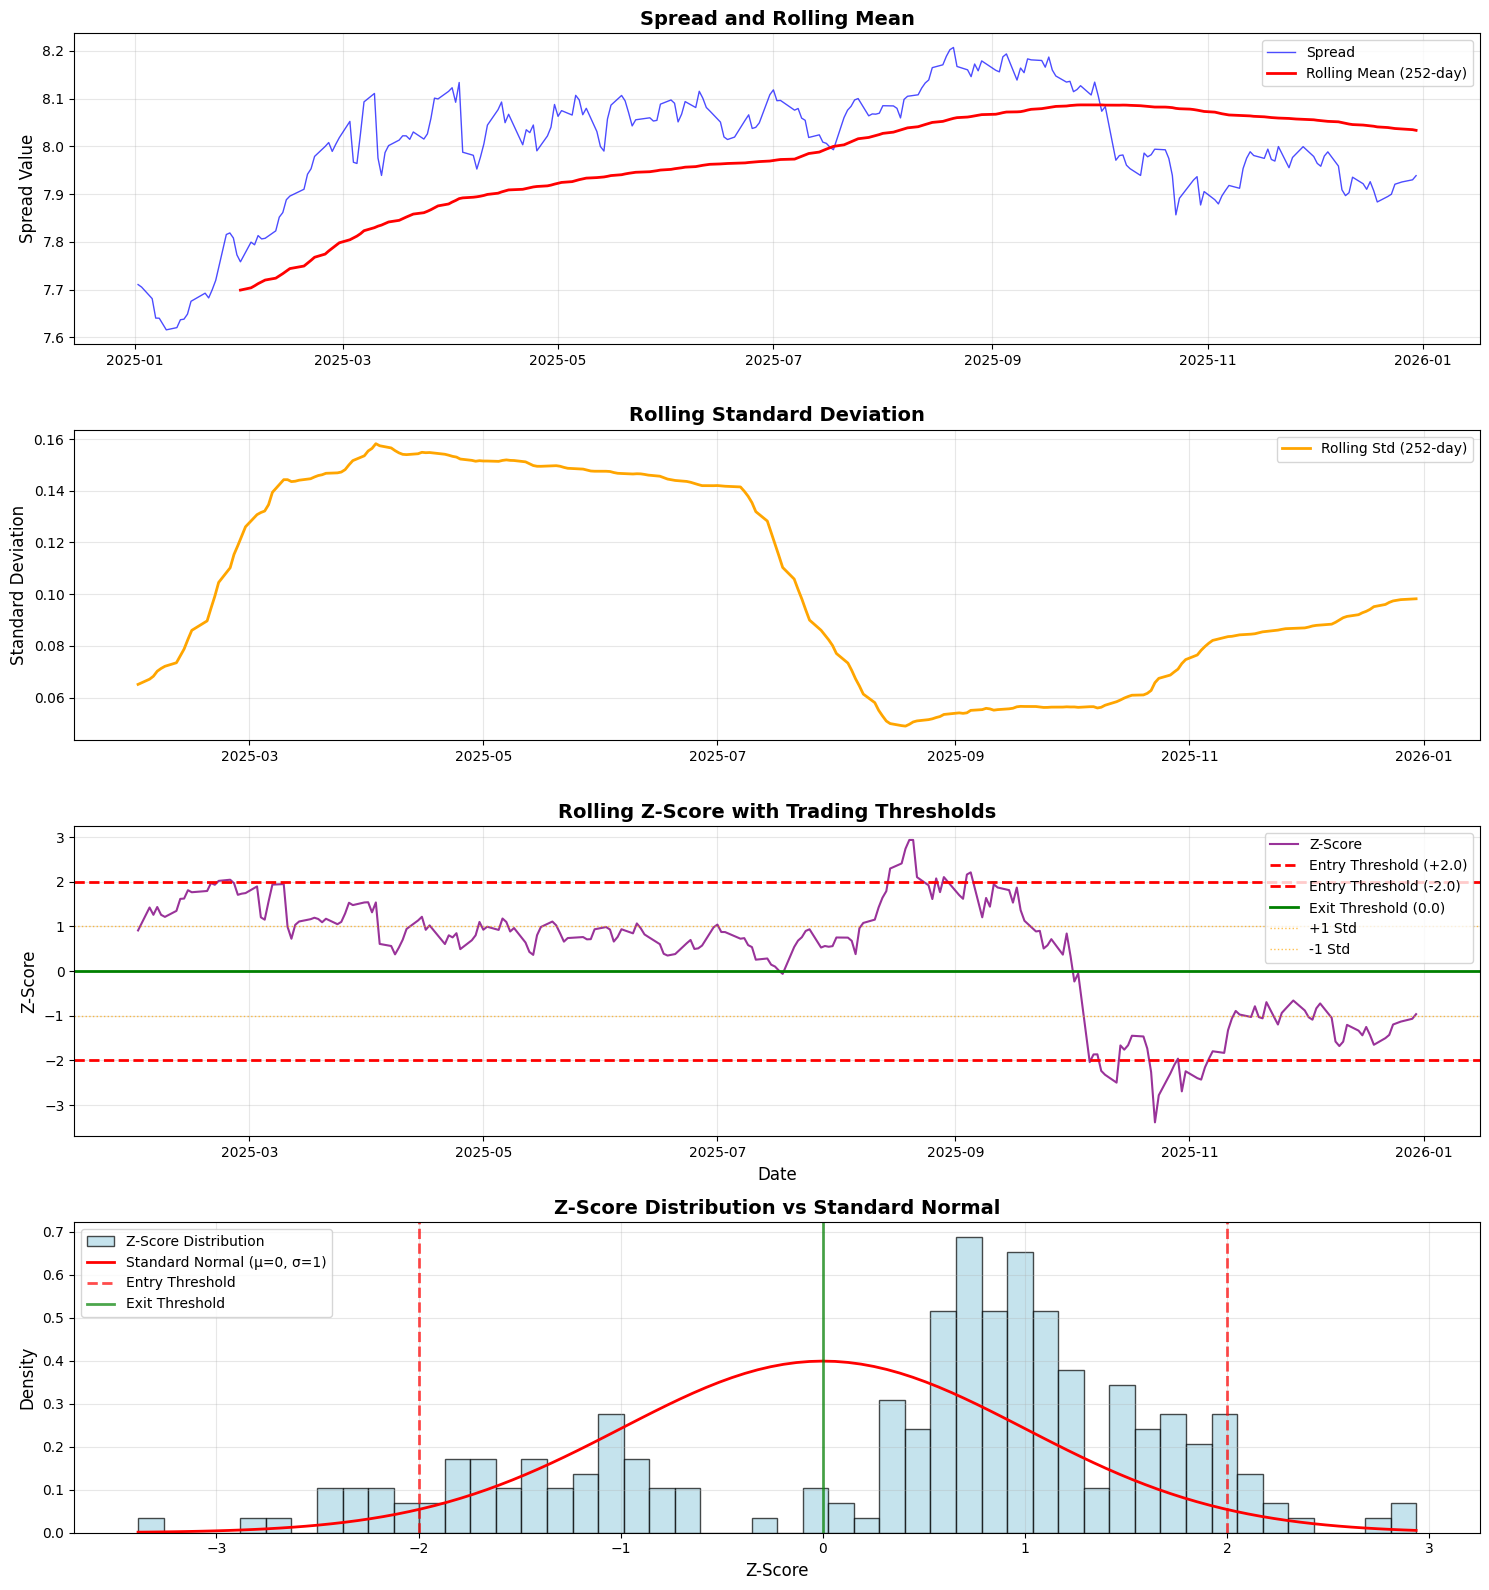


Z-Score Distribution Analysis:
Statistic                 Value          
----------------------------------------
Valid Z-scores            230            
Mean (should be ~0)       0.403281       
Std Dev (should be ~1)    1.308308       
Skewness                  -0.763093      
Kurtosis                  -0.286418      

Trading Signal Analysis:
  Z > +2.0 (Short spread): 12 occurrences (5.22%)
  Z < -2.0 (Long spread): 14 occurrences (6.09%)
  Total entry signals: 26 (11.30%)
  Expected frequency (normal): 10 occurrences (4.55%)


In [56]:
# Visualize rolling Z-score results
if 'zscore_results' in locals() and 'validation_results' in locals():
    print("VISUALIZING ROLLING Z-SCORE RESULTS")
    print("=" * 80)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(4, 1, figsize=(15, 16))
    
    # Get valid data for plotting
    valid_mask = zscore_results['zscore'].notna()
    valid_dates = zscore_results.index[valid_mask]
    valid_zscore = zscore_results['zscore'][valid_mask]
    valid_spread = zscore_results['spread'][valid_mask]
    valid_rolling_mean = zscore_results['rolling_mean'][valid_mask]
    
    # Plot 1: Original spread with rolling mean
    axes[0].plot(zscore_results.index, zscore_results['spread'], linewidth=1, alpha=0.7, color='blue', label='Spread')
    axes[0].plot(zscore_results.index, zscore_results['rolling_mean'], linewidth=2, color='red', label='Rolling Mean (252-day)')
    axes[0].set_title('Spread and Rolling Mean', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Spread Value', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Rolling standard deviation
    axes[1].plot(zscore_results.index, zscore_results['rolling_std'], linewidth=2, color='orange', label='Rolling Std (252-day)')
    axes[1].set_title('Rolling Standard Deviation', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Standard Deviation', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Z-score time series with threshold lines
    axes[2].plot(valid_dates, valid_zscore, linewidth=1.5, color='purple', alpha=0.8, label='Z-Score')
    axes[2].axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Entry Threshold (+2.0)')
    axes[2].axhline(y=-2.0, color='red', linestyle='--', linewidth=2, label='Entry Threshold (-2.0)')
    axes[2].axhline(y=0.0, color='green', linestyle='-', linewidth=2, label='Exit Threshold (0.0)')
    axes[2].axhline(y=1.0, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='+1 Std')
    axes[2].axhline(y=-1.0, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='-1 Std')
    axes[2].set_title('Rolling Z-Score with Trading Thresholds', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Z-Score', fontsize=12)
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Plot 4: Z-score histogram with normal distribution
    valid_zscore_clean = valid_zscore.dropna()
    axes[3].hist(valid_zscore_clean, bins=50, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='Z-Score Distribution')
    
    # Overlay standard normal distribution
    from scipy import stats
    x = np.linspace(valid_zscore_clean.min(), valid_zscore_clean.max(), 100)
    normal_dist = stats.norm.pdf(x, 0, 1)  # Standard normal
    axes[3].plot(x, normal_dist, 'r-', linewidth=2, label='Standard Normal (μ=0, σ=1)')
    
    # Add threshold lines
    axes[3].axvline(x=2.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Entry Threshold')
    axes[3].axvline(x=-2.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    axes[3].axvline(x=0.0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Exit Threshold')
    
    axes[3].set_title('Z-Score Distribution vs Standard Normal', fontsize=14, fontweight='bold')
    axes[3].set_xlabel('Z-Score', fontsize=12)
    axes[3].set_ylabel('Density', fontsize=12)
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis
    print(f"\nZ-Score Distribution Analysis:")
    print(f"{'Statistic':<25} {'Value':<15}")
    print("-" * 40)
    print(f"{'Valid Z-scores':<25} {len(valid_zscore_clean):<15}")
    print(f"{'Mean (should be ~0)':<25} {valid_zscore_clean.mean():<15.6f}")
    print(f"{'Std Dev (should be ~1)':<25} {valid_zscore_clean.std():<15.6f}")
    print(f"{'Skewness':<25} {valid_zscore_clean.skew():<15.6f}")
    print(f"{'Kurtosis':<25} {valid_zscore_clean.kurtosis():<15.6f}")
    
    # Threshold analysis
    above_threshold = (valid_zscore_clean > 2.0).sum()
    below_threshold = (valid_zscore_clean < -2.0).sum()
    total_valid = len(valid_zscore_clean)
    
    print(f"\nTrading Signal Analysis:")
    print(f"  Z > +2.0 (Short spread): {above_threshold} occurrences ({above_threshold/total_valid*100:.2f}%)")
    print(f"  Z < -2.0 (Long spread): {below_threshold} occurrences ({below_threshold/total_valid*100:.2f}%)")
    print(f"  Total entry signals: {above_threshold + below_threshold} ({(above_threshold + below_threshold)/total_valid*100:.2f}%)")
    print(f"  Expected frequency (normal): {total_valid * 0.0455:.0f} occurrences (4.55%)")
    
else:
    print("❌ Z-score results not available - please run previous cells first")

In [57]:
def test_different_zscore_parameters(spread, windows=[126, 252, 504], min_periods_list=[10, 20, 40]):
    """
    Test Z-score calculation with different parameters to find optimal settings.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to calculate Z-scores for
    windows : list, default [126, 252, 504]
        List of rolling window sizes to test (6 months, 1 year, 2 years)
    min_periods_list : list, default [10, 20, 40]
        List of minimum periods to test
        
    Returns:
    --------
    pd.DataFrame
        Comparison of Z-score statistics across different parameters
    """
    print("TESTING DIFFERENT Z-SCORE PARAMETERS")
    print("=" * 80)
    
    parameter_results = []
    
    for window in windows:
        for min_periods in min_periods_list:
            print(f"\nTesting: window={window}, min_periods={min_periods}")
            
            # Calculate Z-scores with these parameters
            zscore_data = calculate_rolling_zscore(spread, window=window, min_periods=min_periods)
            zscore = zscore_data['zscore']
            
            # Calculate statistics
            valid_mask = zscore.notna()
            valid_count = valid_mask.sum()
            total_count = len(zscore)
            valid_percentage = valid_count / total_count * 100
            
            if valid_count > 0:
                valid_zscore = zscore[valid_mask]
                
                # Calculate signal frequency
                entry_signals = (abs(valid_zscore) > 2.0).sum()
                entry_frequency = entry_signals / valid_count * 100
                
                # Calculate extreme value frequency
                extreme_signals = (abs(valid_zscore) > 5.0).sum()
                extreme_frequency = extreme_signals / valid_count * 100
                
                result = {
                    'window': window,
                    'min_periods': min_periods,
                    'valid_count': valid_count,
                    'valid_percentage': valid_percentage,
                    'zscore_mean': valid_zscore.mean(),
                    'zscore_std': valid_zscore.std(),
                    'zscore_min': valid_zscore.min(),
                    'zscore_max': valid_zscore.max(),
                    'entry_signals': entry_signals,
                    'entry_frequency': entry_frequency,
                    'extreme_signals': extreme_signals,
                    'extreme_frequency': extreme_frequency
                }
                
                parameter_results.append(result)
                
                print(f"  Valid data: {valid_count}/{total_count} ({valid_percentage:.1f}%)")
                print(f"  Z-score stats: mean={valid_zscore.mean():.3f}, std={valid_zscore.std():.3f}")
                print(f"  Entry signals: {entry_signals} ({entry_frequency:.2f}%)")
                print(f"  Extreme signals: {extreme_signals} ({extreme_frequency:.2f}%)")
            else:
                print(f"  ❌ No valid Z-scores calculated")
    
    # Convert to DataFrame for easy comparison
    if parameter_results:
        results_df = pd.DataFrame(parameter_results)
        
        print(f"\nPARAMETER COMPARISON SUMMARY")
        print("-" * 120)
        print(f"{'Window':<8} {'Min_Per':<8} {'Valid%':<8} {'Z_Mean':<8} {'Z_Std':<8} {'Entry%':<8} {'Extreme%':<9} {'Range':<12}")
        print("-" * 120)
        
        for _, row in results_df.iterrows():
            range_val = row['zscore_max'] - row['zscore_min']
            print(f"{row['window']:<8} {row['min_periods']:<8} {row['valid_percentage']:<8.1f} "
                  f"{row['zscore_mean']:<8.3f} {row['zscore_std']:<8.3f} {row['entry_frequency']:<8.2f} "
                  f"{row['extreme_frequency']:<9.2f} {range_val:<12.3f}")
        
        print("-" * 120)
        
        # Recommendations
        print(f"\nPARAMETER RECOMMENDATIONS:")
        
        # Find best parameters based on criteria
        sufficient_data = results_df[results_df['valid_percentage'] > 70]
        if len(sufficient_data) > 0:
            best_coverage = sufficient_data.loc[sufficient_data['valid_percentage'].idxmax()]
            print(f"  📊 Best data coverage: window={best_coverage['window']}, min_periods={best_coverage['min_periods']} "
                  f"({best_coverage['valid_percentage']:.1f}% valid)")
        
        # Find parameters with reasonable signal frequency (2-10%)
        reasonable_signals = results_df[(results_df['entry_frequency'] >= 2) & (results_df['entry_frequency'] <= 10)]
        if len(reasonable_signals) > 0:
            best_signals = reasonable_signals.loc[reasonable_signals['entry_frequency'].idxmin()]
            print(f"  🎯 Best signal frequency: window={best_signals['window']}, min_periods={best_signals['min_periods']} "
                  f"({best_signals['entry_frequency']:.2f}% entry signals)")
        
        # Find parameters with stable Z-scores (std close to 1)
        stable_zscore = results_df[(results_df['zscore_std'] >= 0.8) & (results_df['zscore_std'] <= 1.2)]
        if len(stable_zscore) > 0:
            best_stable = stable_zscore.loc[(stable_zscore['zscore_std'] - 1.0).abs().idxmin()]
            print(f"  ⚖️  Most stable Z-scores: window={best_stable['window']}, min_periods={best_stable['min_periods']} "
                  f"(std={best_stable['zscore_std']:.3f})")
        
        return results_df
    else:
        print("❌ No valid parameter combinations found")
        return None

# Test different Z-score parameters
if 'spread' in locals():
    parameter_comparison = test_different_zscore_parameters(spread)
else:
    print("❌ Spread not available - please run previous cells first")

TESTING DIFFERENT Z-SCORE PARAMETERS

Testing: window=126, min_periods=10
Calculating rolling Z-scores with window=126, min_periods=10...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 240 / 249 (96.4%)
Z-score range: [-3.388, 2.935]
Z-score mean: 0.440
Z-score std: 1.303
  Valid data: 240/249 (96.4%)
  Z-score stats: mean=0.440, std=1.303
  Entry signals: 28 (11.67%)
  Extreme signals: 0 (0.00%)

Testing: window=126, min_periods=20
Calculating rolling Z-scores with window=126, min_periods=20...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 230 / 249 (92.4%)
Z-score range: [-3.388, 2.935]
Z-score mean: 0.403
Z-score std: 1.308
  Valid data: 230/249 (92.4%)
  Z-score stats: mean=0.403, std=1.308
  Entry signals: 26 (11.30%)
  Extreme signals: 0 (0.00%)

Testing: window=126, min_periods=40
Calculating rolling Z-scores with window=126, min_periods=40...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 210 / 249 (84.3%)
Z-score range: [-3.388, 2.935]
Z-score me

### 3.2 Implement Signal Logic

Now we'll implement the trading signal logic based on the Z-scores we calculated. The strategy follows a mean reversion approach:

**Trading Rules:**
- **Entry Long Spread**: Z-score < -2.0 (spread is too low) → Long T, Short VZ
- **Entry Short Spread**: Z-score > 2.0 (spread is too high) → Short T, Long VZ  
- **Exit**: Z-score crosses 0 (spread reverts to mean) → Close positions

**Position Sizing Options:**
1. **Fixed Allocation**: Equal dollar allocation to each leg
2. **Volatility-Based**: Scale positions by inverse volatility

In [58]:
def generate_trading_signals(zscore_results, entry_threshold=2.0, exit_threshold=0.0):
    """
    Generate trading signals based on Z-score thresholds.
    
    Parameters:
    -----------
    zscore_results : pd.DataFrame
        DataFrame containing Z-scores from calculate_rolling_zscore
    entry_threshold : float, default 2.0
        Z-score threshold for entry signals
    exit_threshold : float, default 0.0
        Z-score threshold for exit signals (mean reversion)
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with trading signals and positions
    """
    print(f"GENERATING TRADING SIGNALS")
    print(f"Entry threshold: ±{entry_threshold}, Exit threshold: {exit_threshold}")
    print("=" * 60)
    
    # Create a copy to avoid modifying original data
    signals = zscore_results.copy()
    
    # Ensure index is timezone-naive for consistency
    if hasattr(signals.index, 'tz') and signals.index.tz is not None:
        signals.index = signals.index.tz_localize(None)
    
    # Initialize signal columns with proper dtypes
    signals['signal'] = 0  # 0: no signal, 1: long spread, -1: short spread
    signals['position'] = 0  # Current position (same encoding as signal)
    signals['entry_date'] = pd.NaT
    signals['exit_date'] = pd.NaT
    signals['hold_period'] = 0  # Days in position
    
    # Get valid Z-scores
    valid_mask = signals['zscore'].notna()
    valid_dates = signals.index[valid_mask]
    valid_zscore = signals.loc[valid_mask, 'zscore']
    
    if len(valid_zscore) == 0:
        print("❌ No valid Z-scores found for signal generation")
        return signals
    
    # Generate entry signals
    print("Generating entry signals...")
    
    # Long spread signal: Z-score < -entry_threshold
    long_signals = valid_zscore < -entry_threshold
    signals.loc[valid_mask & long_signals, 'signal'] = 1
    
    # Short spread signal: Z-score > entry_threshold  
    short_signals = valid_zscore > entry_threshold
    signals.loc[valid_mask & short_signals, 'signal'] = -1
    
    # Track positions and exits
    current_position = 0
    entry_date_idx = None
    
    print("Processing position logic...")
    
    for i, date in enumerate(valid_dates):
        current_signal = signals.loc[date, 'signal']
        current_zscore = signals.loc[date, 'zscore']
        
        # Check for exit signal (crossing 0)
        if current_position != 0:
            # Exit when Z-score crosses 0 in the direction of mean reversion
            if (current_position == 1 and current_zscore >= exit_threshold) or \
               (current_position == -1 and current_zscore <= exit_threshold):
                signals.loc[date, 'position'] = 0  # Exit
                # Use .value to ensure timezone-naive datetime
                signals.at[date, 'exit_date'] = pd.Timestamp(date)
                
                # Calculate hold period
                if entry_date_idx is not None:
                    hold_days = (date - valid_dates[entry_date_idx]).days
                    signals.at[date, 'hold_period'] = hold_days
                
                current_position = 0
                entry_date_idx = None
            else:
                # Maintain current position
                signals.loc[date, 'position'] = current_position
                
                # Update hold period
                if entry_date_idx is not None:
                    hold_days = (date - valid_dates[entry_date_idx]).days
                    signals.at[date, 'hold_period'] = hold_days
        else:
            # Check for entry signal
            if current_signal != 0:
                signals.loc[date, 'position'] = current_signal
                # Use .at and pd.Timestamp to ensure timezone-naive datetime
                signals.at[date, 'entry_date'] = pd.Timestamp(date)
                current_position = current_signal
                entry_date_idx = i
    
    # Signal statistics
    total_periods = len(signals)
    entry_signals = (signals['signal'] != 0).sum()
    long_entries = (signals['signal'] == 1).sum()
    short_entries = (signals['signal'] == -1).sum()
    exits = signals['exit_date'].notna().sum()
    
    print(f"\nSIGNAL GENERATION RESULTS:")
    print(f"Total periods: {total_periods}")
    print(f"Entry signals: {entry_signals} ({entry_signals/total_periods*100:.2f}%)")
    print(f"  Long spread entries: {long_entries} ({long_entries/total_periods*100:.2f}%)")
    print(f"  Short spread entries: {short_entries} ({short_entries/total_periods*100:.2f}%)")
    print(f"Exit signals: {exits}")
    
    # Position statistics
    positions = signals['position'] != 0
    position_periods = positions.sum()
    max_hold_period = signals['hold_period'].max()
    avg_hold_period = signals.loc[signals['hold_period'] > 0, 'hold_period'].mean()
    
    print(f"\nPOSITION STATISTICS:")
    print(f"Periods in position: {position_periods} ({position_periods/total_periods*100:.2f}%)")
    print(f"Max hold period: {max_hold_period} days")
    print(f"Avg hold period: {avg_hold_period:.1f} days" if not pd.isna(avg_hold_period) else "Avg hold period: N/A")
    
    return signals

# Generate trading signals
if 'zscore_results' in locals():
    trading_signals = generate_trading_signals(zscore_results, entry_threshold=2.0, exit_threshold=0.0)
    
    # Display first few signals
    print(f"\nFirst 10 trading signals:")
    display_cols = ['zscore', 'signal', 'position', 'entry_date', 'exit_date', 'hold_period']
    print(trading_signals[display_cols].head(10))
    
    # Display last few signals  
    print(f"\nLast 10 trading signals:")
    print(trading_signals[display_cols].tail(10))
else:
    print("❌ Z-score results not available - please run previous cells first")

GENERATING TRADING SIGNALS
Entry threshold: ±2.0, Exit threshold: 0.0
Generating entry signals...
Processing position logic...

SIGNAL GENERATION RESULTS:
Total periods: 249
Entry signals: 26 (10.44%)
  Long spread entries: 14 (5.62%)
  Short spread entries: 12 (4.82%)
Exit signals: 2

POSITION STATISTICS:
Periods in position: 194 (77.91%)
Max hold period: 147 days
Avg hold period: 55.9 days

First 10 trading signals:
            zscore  signal  position entry_date exit_date  hold_period
date                                                                  
2025-01-02     NaN       0         0        NaT       NaT            0
2025-01-03     NaN       0         0        NaT       NaT            0
2025-01-06     NaN       0         0        NaT       NaT            0
2025-01-07     NaN       0         0        NaT       NaT            0
2025-01-08     NaN       0         0        NaT       NaT            0
2025-01-10     NaN       0         0        NaT       NaT            0
2025-01-13

In [59]:
def calculate_position_sizes(signals, prices_data, method='fixed', total_capital=100000):
    """
    Calculate position sizes for each leg of the spread trade.
    
    Parameters:
    -----------
    signals : pd.DataFrame  
        DataFrame with trading signals and positions
    prices_data : pd.DataFrame
        DataFrame with price data for T and VZ
    method : str, default 'fixed'
        Position sizing method: 'fixed' or 'volatility_based'
    total_capital : float, default 100000
        Total capital to allocate
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with position sizes and dollar allocations
    """
    print("=" * 60)
    print(f"*Method: {method}, Total Capital: ${total_capital:,.0f}")
    
    # Create result dataframe
    positions = signals.copy()
    
    # Initialize position size columns
    positions['t_shares'] = 0.0
    positions['vz_shares'] = 0.0  
    positions['t_dollars'] = 0.0
    positions['vz_dollars'] = 0.0
    positions['total_exposure'] = 0.0
    
    # Get price data
    if 'T' not in prices_data.columns or 'VZ' not in prices_data.columns:
        print("❌ Price data must contain 'T' and 'VZ' columns")
        return positions
    
    # Ensure prices_data index is timezone-naive to match positions index
    if hasattr(prices_data.index, 'tz') and prices_data.index.tz is not None:
        prices_data = prices_data.copy()
        prices_data.index = prices_data.index.tz_localize(None)
        
    # Align price data with signals
    common_dates = positions.index.intersection(prices_data.index)
    positions = positions.loc[common_dates]
    aligned_prices = prices_data.loc[common_dates]
    
    if method == 'fixed':
        # Fixed allocation: 50% capital to each leg when in position
        capital_per_leg = total_capital * 0.5
        
        for date in positions.index:
            position = positions.loc[date, 'position']
            t_price = aligned_prices.loc[date, 'T']
            vz_price = aligned_prices.loc[date, 'VZ']
            
            if position == 1:  # Long spread: Long T, Short VZ
                positions.loc[date, 't_shares'] = capital_per_leg / t_price
                positions.loc[date, 't_dollars'] = capital_per_leg
                positions.loc[date, 'vz_shares'] = -capital_per_leg / vz_price  # Short
                positions.loc[date, 'vz_dollars'] = -capital_per_leg
                positions.loc[date, 'total_exposure'] = capital_per_leg + capital_per_leg
                
            elif position == -1:  # Short spread: Short T, Long VZ
                positions.loc[date, 't_shares'] = -capital_per_leg / t_price  # Short
                positions.loc[date, 't_dollars'] = -capital_per_leg
                positions.loc[date, 'vz_shares'] = capital_per_leg / vz_price
                positions.loc[date, 'vz_dollars'] = capital_per_leg  
                positions.loc[date, 'total_exposure'] = capital_per_leg + capital_per_leg
                
            # position == 0: No position (all zeros)
    
    elif method == 'volatility_based':        
        # Calculate rolling volatility (20-day)
        returns = aligned_prices.pct_change()
        rolling_vol = returns.rolling(window=20).std() * np.sqrt(252)  # Annualized
        
        # Inverse volatility weights
        for date in positions.index:
            position = positions.loc[date, 'position']
            t_price = aligned_prices.loc[date, 'T']
            vz_price = aligned_prices.loc[date, 'VZ']
            
            if position != 0:
                # Get volatilities (use last available if current is NaN)
                t_vol = rolling_vol.loc[:date, 'T'].dropna().iloc[-1] if not rolling_vol.loc[:date, 'T'].dropna().empty else 0.2
                vz_vol = rolling_vol.loc[:date, 'VZ'].dropna().iloc[-1] if not rolling_vol.loc[:date, 'VZ'].dropna().empty else 0.2
                
                # Inverse volatility weights
                inv_t_vol = 1 / t_vol if t_vol > 0 else 1
                inv_vz_vol = 1 / vz_vol if vz_vol > 0 else 1
                total_inv_vol = inv_t_vol + inv_vz_vol
                
                t_weight = inv_t_vol / total_inv_vol
                vz_weight = inv_vz_vol / total_inv_vol
                
                t_capital = total_capital * t_weight
                vz_capital = total_capital * vz_weight
                
                if position == 1:  # Long spread: Long T, Short VZ
                    positions.loc[date, 't_shares'] = t_capital / t_price
                    positions.loc[date, 't_dollars'] = t_capital
                    positions.loc[date, 'vz_shares'] = -vz_capital / vz_price  # Short
                    positions.loc[date, 'vz_dollars'] = -vz_capital
                    positions.loc[date, 'total_exposure'] = t_capital + vz_capital
                    
                elif position == -1:  # Short spread: Short T, Long VZ
                    positions.loc[date, 't_shares'] = -t_capital / t_price  # Short
                    positions.loc[date, 't_dollars'] = -t_capital
                    positions.loc[date, 'vz_shares'] = vz_capital / vz_price
                    positions.loc[date, 'vz_dollars'] = vz_capital
                    positions.loc[date, 'total_exposure'] = t_capital + vz_capital
    
    else:
        print(f"❌ Unknown position sizing method: {method}")
        return positions
    
    # Position statistics
    active_positions = positions['position'] != 0
    periods_in_position = active_positions.sum()
    
    if periods_in_position > 0:
        avg_t_exposure = positions.loc[active_positions, 't_dollars'].abs().mean()
        avg_vz_exposure = positions.loc[active_positions, 'vz_dollars'].abs().mean()
        avg_total_exposure = positions.loc[active_positions, 'total_exposure'].mean()
        
        print(f" POSITION SIZING RESULTS:")
        print(f"Periods in position: {periods_in_position}")
        print(f"Average T exposure: ${avg_t_exposure:,.0f}")
        print(f"Average VZ exposure: ${avg_vz_exposure:,.0f}")
        print(f"Average total exposure: ${avg_total_exposure:,.0f}")
        
        # Show sample positions
        # print(f"\nSample positions:")
        # sample_cols = ['position', 't_shares', 'vz_shares', 't_dollars', 'vz_dollars', 'total_exposure']
        # sample_positions = positions[active_positions][sample_cols].head(5)
        # print(sample_positions)
    
    return positions

# Calculate position sizes (using price data from earlier cells)
if 'trading_signals' in locals() and 'close_prices' in locals():
    print(f"CALCULATING POSITION SIZES")
    # Fixed allocation
    fixed_positions = calculate_position_sizes(trading_signals, close_prices, method='fixed', total_capital=100000)
    
    # Volatility-based allocation  
    vol_positions = calculate_position_sizes(trading_signals, close_prices, method='volatility_based', total_capital=100000)
    
    print(f"\nComparison of position sizing methods:")
    print(f"Fixed allocation periods in position: {(fixed_positions['position'] != 0).sum()}")
    print(f"Volatility-based periods in position: {(vol_positions['position'] != 0).sum()}")
    
else:
    print("❌ Required data not available - please run previous cells first")

CALCULATING POSITION SIZES
*Method: fixed, Total Capital: $100,000
 POSITION SIZING RESULTS:
Periods in position: 194
Average T exposure: $50,000
Average VZ exposure: $50,000
Average total exposure: $100,000
*Method: volatility_based, Total Capital: $100,000
 POSITION SIZING RESULTS:
Periods in position: 194
Average T exposure: $48,871
Average VZ exposure: $51,129
Average total exposure: $100,000

Comparison of position sizing methods:
Fixed allocation periods in position: 194
Volatility-based periods in position: 194


In [60]:
def analyze_signal_performance(signals, positions, prices_data):
    """
    Analyze the performance of trading signals.
    
    Parameters:
    -----------
    signals : pd.DataFrame
        DataFrame with trading signals
    positions : pd.DataFrame  
        DataFrame with position sizes
    prices_data : pd.DataFrame
        DataFrame with price data for T and VZ
        
    Returns:
    --------
    dict
        Performance statistics and analysis
    """
    print("ANALYZING SIGNAL PERFORMANCE")
    print("=" * 60)
    
    # Ensure all dataframes have timezone-naive indices
    def make_timezone_naive(df):
        if hasattr(df.index, 'tz') and df.index.tz is not None:
            df = df.copy()
            df.index = df.index.tz_localize(None)
        return df
    
    signals = make_timezone_naive(signals)
    positions = make_timezone_naive(positions)
    prices_data = make_timezone_naive(prices_data)
    
    # Combine signals and positions
    analysis_data = signals.copy()
    
    # Add position data
    position_cols = ['t_shares', 'vz_shares', 't_dollars', 'vz_dollars', 'total_exposure']
    for col in position_cols:
        if col in positions.columns:
            analysis_data[col] = positions[col]
    
    # Add price data
    price_cols = ['T', 'VZ']
    for col in price_cols:
        if col in prices_data.columns:
            analysis_data[f'{col}_price'] = prices_data[col]
    
    # Calculate daily P&L
    analysis_data['t_daily_pnl'] = 0.0
    analysis_data['vz_daily_pnl'] = 0.0
    analysis_data['total_daily_pnl'] = 0.0
    analysis_data['cumulative_pnl'] = 0.0
    
    # Get valid dates with all data
    valid_mask = (
        analysis_data['t_shares'].notna() & 
        analysis_data['vz_shares'].notna() &
        analysis_data['T_price'].notna() & 
        analysis_data['VZ_price'].notna()
    )
    
    valid_data = analysis_data[valid_mask].copy()
    
    if len(valid_data) == 0:
        print("❌ No valid data for performance analysis")
        return {}
    
    # Calculate daily returns and P&L
    valid_data['t_returns'] = valid_data['T_price'].pct_change()
    valid_data['vz_returns'] = valid_data['VZ_price'].pct_change()
    
    # Daily P&L = position_size * price_return
    valid_data['t_daily_pnl'] = valid_data['t_shares'] * valid_data['T_price'] * valid_data['t_returns']
    valid_data['vz_daily_pnl'] = valid_data['vz_shares'] * valid_data['VZ_price'] * valid_data['vz_returns']
    valid_data['total_daily_pnl'] = valid_data['t_daily_pnl'] + valid_data['vz_daily_pnl']
    
    # Cumulative P&L
    valid_data['cumulative_pnl'] = valid_data['total_daily_pnl'].cumsum()
    
    # Trade analysis
    trades = []
    current_trade = None
    
    for i, (date, row) in enumerate(valid_data.iterrows()):
        position = row['position']
        
        # Entry signal
        if position != 0 and (current_trade is None or current_trade['exit_date'] is not None):
            # New trade starts
            current_trade = {
                'entry_date': pd.Timestamp(date),  # Ensure timezone-naive
                'entry_zscore': row['zscore'],
                'direction': 'long_spread' if position == 1 else 'short_spread',
                'entry_t_price': row['T_price'],
                'entry_vz_price': row['VZ_price'],
                'exit_date': None,
                'exit_zscore': None,
                'exit_t_price': None,
                'exit_vz_price': None,
                'pnl': 0.0,
                'hold_period': 0,
                'entry_t_shares': row['t_shares'],
                'entry_vz_shares': row['vz_shares']
            }
        
        # Exit signal
        elif position == 0 and current_trade is not None and current_trade['exit_date'] is None:
            # Trade ends
            current_trade['exit_date'] = pd.Timestamp(date)  # Ensure timezone-naive
            current_trade['exit_zscore'] = row['zscore']
            current_trade['exit_t_price'] = row['T_price']
            current_trade['exit_vz_price'] = row['VZ_price']
            current_trade['hold_period'] = (date - current_trade['entry_date']).days
            
            # Calculate trade P&L (using cumulative P&L at exit)
            current_trade['pnl'] = row['cumulative_pnl']
            
            # Add to completed trades
            trades.append(current_trade.copy())
            current_trade['exit_date'] = pd.Timestamp(date)  # Mark as completed
    
    # Convert trades to DataFrame
    if trades:
        trades_df = pd.DataFrame(trades)
        
        # Trade statistics
        total_trades = len(trades_df)
        winning_trades = (trades_df['pnl'] > 0).sum()
        losing_trades = (trades_df['pnl'] <= 0).sum()
        win_rate = winning_trades / total_trades * 100 if total_trades > 0 else 0
        
        total_pnl = trades_df['pnl'].sum()
        avg_trade_pnl = trades_df['pnl'].mean()
        avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean() if winning_trades > 0 else 0
        avg_loss = trades_df[trades_df['pnl'] <= 0]['pnl'].mean() if losing_trades > 0 else 0
        
        avg_hold_period = trades_df['hold_period'].mean()
        
        print(f"TRADE PERFORMANCE RESULTS:")
        print(f"Total trades: {total_trades}")
        print(f"Winning trades: {winning_trades} ({win_rate:.1f}%)")
        print(f"Losing trades: {losing_trades} ({100-win_rate:.1f}%)")
        print(f"Total P&L: ${total_pnl:,.0f}")
        print(f"Average trade P&L: ${avg_trade_pnl:,.0f}")
        print(f"Average win: ${avg_win:,.0f}")
        print(f"Average loss: ${avg_loss:,.0f}")
        print(f"Average hold period: {avg_hold_period:.1f} days")
        
        # Performance by direction
        long_trades = trades_df[trades_df['direction'] == 'long_spread']
        short_trades = trades_df[trades_df['direction'] == 'short_spread']
        
        print(f"\nPERFORMANCE BY DIRECTION:")
        print(f"Long spread trades: {len(long_trades)}")
        if len(long_trades) > 0:
            long_win_rate = (long_trades['pnl'] > 0).sum() / len(long_trades) * 100
            long_avg_pnl = long_trades['pnl'].mean()
            print(f"  Win rate: {long_win_rate:.1f}%, Avg P&L: ${long_avg_pnl:,.0f}")
        
        print(f"Short spread trades: {len(short_trades)}")
        if len(short_trades) > 0:
            short_win_rate = (short_trades['pnl'] > 0).sum() / len(short_trades) * 100
            short_avg_pnl = short_trades['pnl'].mean()
            print(f"  Win rate: {short_win_rate:.1f}%, Avg P&L: ${short_avg_pnl:,.0f}")
        
        # Show sample trades
        print(f"\nSAMPLE TRADES:")
        sample_cols = ['entry_date', 'direction', 'entry_zscore', 'exit_zscore', 'hold_period', 'pnl']
        print(trades_df[sample_cols].head(10))
        
        return {
            'trades_df': trades_df,
            'valid_data': valid_data,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'total_pnl': total_pnl,
            'avg_trade_pnl': avg_trade_pnl,
            'avg_hold_period': avg_hold_period
        }
    
    else:
        print("❌ No completed trades found")
        return {}

# Analyze signal performance
if 'trading_signals' in locals() and 'fixed_positions' in locals() and 'close_prices' in locals():
    performance_results = analyze_signal_performance(trading_signals, fixed_positions, close_prices)
else:
    print("❌ Required data not available for performance analysis")

ANALYZING SIGNAL PERFORMANCE
TRADE PERFORMANCE RESULTS:
Total trades: 2
Winning trades: 0 (0.0%)
Losing trades: 2 (100.0%)
Total P&L: $-3,388
Average trade P&L: $-1,694
Average win: $0
Average loss: $-1,694
Average hold period: 97.5 days

PERFORMANCE BY DIRECTION:
Long spread trades: 0
Short spread trades: 2
  Win rate: 0.0%, Avg P&L: $-1,694

SAMPLE TRADES:
  entry_date     direction  entry_zscore  exit_zscore  hold_period  \
0 2025-02-21  short_spread      2.018487    -0.063415          147   
1 2025-08-15  short_spread      2.294810    -0.234351           48   

           pnl  
0 -2939.622523  
1  -448.831588  
